In [118]:
# Import Libraries and modules

# libraries that are used for analysis and visualization

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [119]:
# Impoting data preprocessing libraries
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [120]:
# Importing model selection libraries.
from sklearn.model_selection import train_test_split


In [121]:
# Importing metrics for model evaluation.
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score,roc_curve, roc_auc_score

In [122]:
# Importing machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

load the CARDIOVASCULAR RISK DATA

In [123]:
#Dataset First View
risk_df=pd.read_csv('cardiovascular_risk_data.csv',na_values=["NA", "N/A", "null", "None", "?", "-"])

# Viewing the top 5 rows to take a glimpse of the data
risk_df.head(5)

,id,age,education,sex,is_smoking,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,0,64,2.0,F,YES,3.0,0.0,0,0,0,221.0,148.0,85.0,NaN,90.0,80.0,1
1,1,36,4.0,M,NO,0.0,0.0,0,1,0,212.0,168.0,98.0,29.77,72.0,75.0,0
2,2,46,1.0,F,YES,10.0,0.0,0,0,0,250.0,116.0,71.0,20.35,88.0,94.0,0
3,3,50,1.0,M,YES,20.0,0.0,0,1,0,233.0,158.0,88.0,28.26,68.0,94.0,1
4,4,64,1.0,F,YES,30.0,0.0,0,0,0,241.0,136.5,85.0,26.42,70.0,77.0,0


In [124]:
# Viewing the last 5 rows
risk_df.tail(5)

,id,age,education,sex,is_smoking,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
3385,3385,60,1.0,F,NO,0.0,0.0,0,0,0,261.0,123.5,79.0,29.28,70.0,103.0,0
3386,3386,46,1.0,F,NO,0.0,0.0,0,0,0,199.0,102.0,56.0,21.96,80.0,84.0,0
3387,3387,44,3.0,M,YES,3.0,0.0,0,1,0,352.0,164.0,119.0,28.92,73.0,72.0,1
3388,3388,60,1.0,M,NO,0.0,NaN,0,1,0,191.0,167.0,105.0,23.01,80.0,85.0,0
3389,3389,54,3.0,F,NO,0.0,0.0,0,0,0,288.0,124.0,77.0,29.88,79.0,92.0,0


In [125]:
# Dataset Rows & Columns 
risk_df.shape

(3390, 17)

In [126]:
print(f'number of rows : {risk_df.shape[0]}  \nnumber of columns : {risk_df.shape[1]}')

number of rows : 3390  
number of columns : 17


### Dataset Information

In [127]:
risk_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3390 entries, 0 to 3389
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               3390 non-null   int64  
 1   age              3390 non-null   int64  
 2   education        3303 non-null   float64
 3   sex              3390 non-null   str    
 4   is_smoking       3390 non-null   str    
 5   cigsPerDay       3368 non-null   float64
 6   BPMeds           3346 non-null   float64
 7   prevalentStroke  3390 non-null   int64  
 8   prevalentHyp     3390 non-null   int64  
 9   diabetes         3390 non-null   int64  
 10  totChol          3352 non-null   float64
 11  sysBP            3390 non-null   float64
 12  diaBP            3390 non-null   float64
 13  BMI              3376 non-null   float64
 14  heartRate        3389 non-null   float64
 15  glucose          3086 non-null   float64
 16  TenYearCHD       3390 non-null   int64  
dtypes: float64(9), int64(6), 

## Duplicate Values

### How important is it to get rid of duplicate records in my data?

The mere presence of repeated data in the dataset is referred to as "duplication." This could be caused by incorrect data entry or procedures for collecting data. We can save time and money by not sending the same data to the machine learning model multiple times by removing duplicate data from our set.

In [128]:
# Checking Duplicate Values
risk_df.duplicated().sum()

np.int64(0)

Insight: We found that there were no duplicate entries in the above data.

In [129]:
'''drop id column'''
risk_df=risk_df.drop(['id'],axis=1,errors='ignore')

## Missing Values/Null Values

### Why dealing with missing values is necessary?
There are frequently a lot of missing values in the actual data. Corrupted or missing data may result in missing values. Since many machine-learning algorithms do not support missing values, missing data must be handled during the dataset's pre-processing. Therefore, we begin by looking for values that are missing.

In [130]:
# Missing Values/Null Values Count
risk_df.isnull().sum()

age                  0
education           87
sex                  0
is_smoking           0
cigsPerDay          22
BPMeds              44
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             38
sysBP                0
diaBP                0
BMI                 14
heartRate            1
glucose            304
TenYearCHD           0
dtype: int64

Insight: We can see there are null values present in totChol, BMI, glucose, BPMeds, cigsPerDay, education has some null values and heartRate has 1 null value.

In [131]:
# Missing Values Percentage
round(risk_df.isnull().sum()/len(risk_df)*100,2)

age                0.00
education          2.57
sex                0.00
is_smoking         0.00
cigsPerDay         0.65
BPMeds             1.30
prevalentStroke    0.00
prevalentHyp       0.00
diabetes           0.00
totChol            1.12
sysBP              0.00
diaBP              0.00
BMI                0.41
heartRate          0.03
glucose            8.97
TenYearCHD         0.00
dtype: float64

### Insight: glucose column has significant number of missing values

<Axes: >

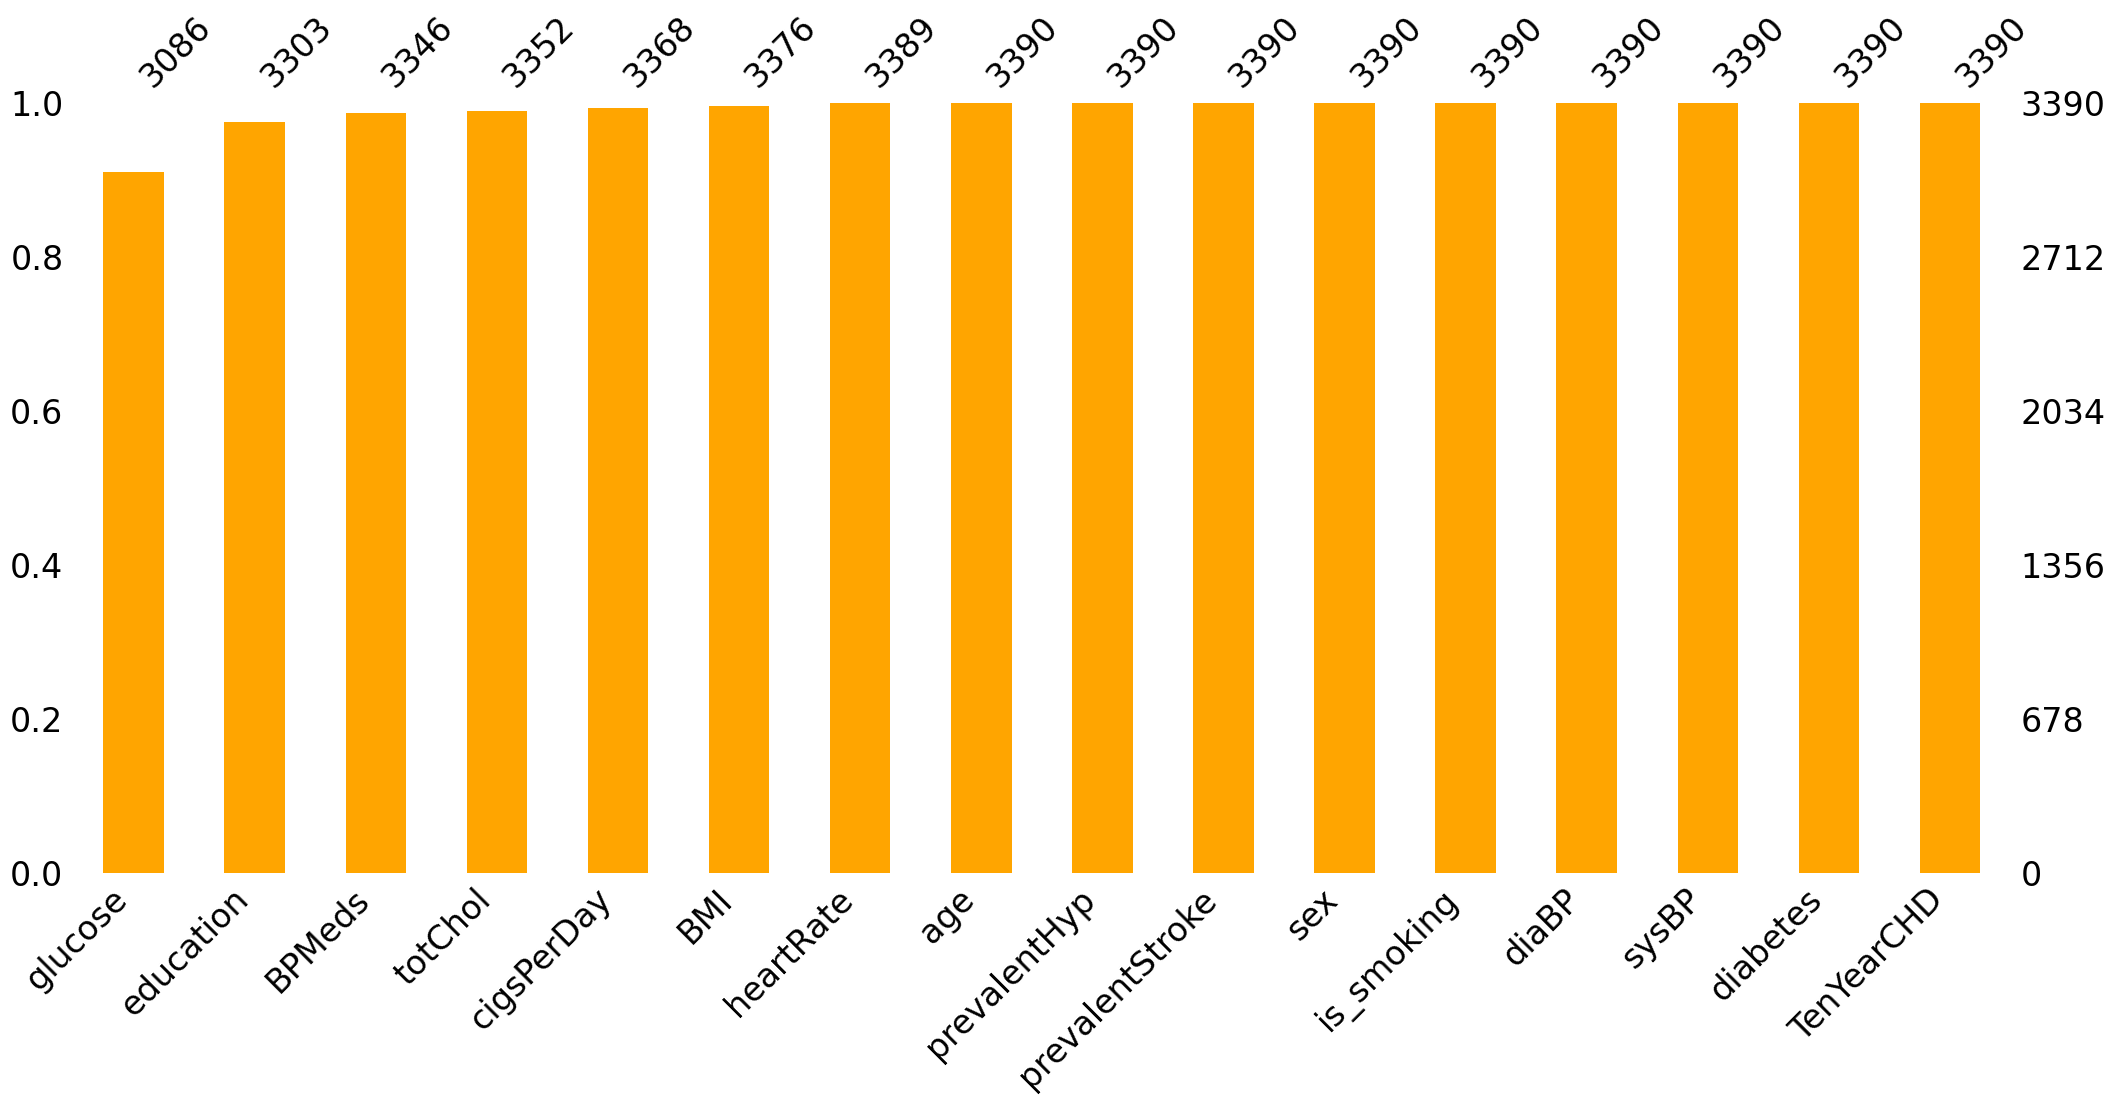

In [132]:
# Visualizing the missing values
import missingno as msno
msno.bar(risk_df,color='orange',sort='ascending',fontsize=24)

<Axes: >

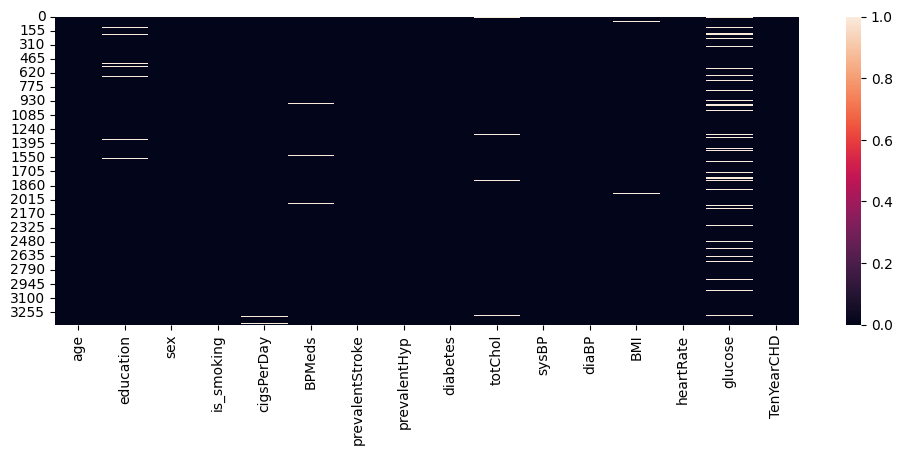

In [133]:
# Visualizing the missing values using Heatmap
plt.figure(figsize=(12,4))
sns.heatmap(risk_df.isna())

### Insight: There is no relation between any columns for missingness
if there would be same pattern for white lines in heatmap then it means two columns missingness have same relation, also if white lines are clustered in some part of a column then we say it is not MCAR but MAR or MNAR and data may be time-ordered or rows represents specific subgroups or dataset made by merging data

## What did you know about your dataset?

The data comes from an ongoing cardiovascular study of Framingham, Massachusetts, residents. The purpose of the classification is to determine whether the patient is at risk for coronary heart disease (CHD) in the ten years to come. The data about the patients is provided by the dataset. It incorporates more than 4,000 records and 15 ascribes.
 
 A classification algorithm is a method of supervised learning that divides data into various classes by utilizing data training. Data or observations are used to train classification predictive modeling, and new observations are categorized into classes or groups.
 
 There are 3390 rows and 16 columns in the dataset. In the 'education', 'cigsPerDay', 'BPMeds', 'totChol', 'BMI', 'heartRate', and 'glucose', there are missing values. The dataset does not contain any duplicate values.
 
 A potential risk factor exists for each attribute. Demographic, behavioral, and medical risk factors are these characteristics.

 First, we should try to understand the dataset through EDA, and then we can deal with null values later.

In [134]:
#Understanding Your Variables
risk_df.columns

Index(['age', 'education', 'sex', 'is_smoking', 'cigsPerDay', 'BPMeds',
       'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP',
       'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD'],
      dtype='str')

###  Statistical Summary

In [135]:
# Dataset Describe    (used to get statistics of numerical columns)
risk_df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,3390.0,49.542183,8.592878,32.00,42.00,49.00,56.00,70.0
education,3303.0,1.970936,1.019081,1.00,1.00,2.00,3.00,4.0
cigsPerDay,3368.0,9.069477,11.879078,0.00,0.00,0.00,20.00,70.0
BPMeds,3346.0,0.029886,0.170299,0.00,0.00,0.00,0.00,1.0
prevalentStroke,3390.0,0.006490,0.080309,0.00,0.00,0.00,0.00,1.0
prevalentHyp,3390.0,0.315339,0.464719,0.00,0.00,0.00,1.00,1.0
diabetes,3390.0,0.025664,0.158153,0.00,0.00,0.00,0.00,1.0
totChol,3352.0,237.074284,45.247430,107.00,206.00,234.00,264.00,696.0
sysBP,3390.0,132.601180,22.292030,83.50,117.00,128.50,144.00,295.0
diaBP,3390.0,82.883038,12.023581,48.00,74.50,82.00,90.00,142.5


## How to analyze
### diaBP feature
mean=82.8, median=82 approx equal hence not skewed, the distribution is usually symmetric

Compare Quartile Distances
median-Q1=82-74=8
Q3-median=90-82=8 
hence distribution is very symmetric.

Detecting Outliers (Using IQR Rule)
IQR=Q3−Q1=90-74=16
Q1−1.5×IQR=74-1.5(16)=50
Q3+1.5×IQR=90+1.5(16)=114

min=48, max=142 hence outliers exist

Most values fall between mean-std , mean+std

 As can be seen in the statistical summary, there is skewness and outliers present in the continuous features 'cigsperday', 'totchol', 'sysbp', 'diebp', 'BMI', 'heartrate', and 'glucose' because there is such a large difference between the 75% percentile value and the maximum value.

In [136]:
#  Variables Description

**Demographic**

*age  : Age of the patient (Continuous - Although the recorded ages have been truncated to whole numbers, the concept of age is continuous)

education : level of education from 1 to 4 (Ordinal Variable)

sex : male or female ("M" or "F")*




**Behavioral**

*is_smoking : whether or not the patient is a current smoker ("YES" or "NO")

cigsPerDay : the number of cigarettes that the person smoked on average in one day (can be considered continuous as one can have any number of cigarettes, even half a cigarette.)
*



**Medical( history)**

*BPMeds : whether or not the patient was on blood pressure medication (Nominal)

prevalentStroke : whether or not the patient had previously had a stroke (Nominal)

prevalentHyp :whether or not the patient was hypertensive (Nominal)

diabetes : whether or not the patient had diabetes (Nominal)*



**Medical(current)**

*totChol :total cholesterol level (Continuous)

sysBP : systolic blood pressure (Continuous)

diaBP : diastolic blood pressure (Continuous)

BMI : Body Mass Index (Continuous)

heartRate : heart rate (Continuous - In medical research, variables such as heart rate though in fact 
discrete, yet are considered continuous because of large number of possible values.)

glucose : glucose level (Continuous)*



**Predict variable (desired target)**

TenYearCHD :(binary: “1”, means “Yes”, “0” means “No”)**

In [137]:
#Check Unique Values for each variable.
# this helps in Detect Data Errors, Remove useless columns, Decide encoding strategy

for i in risk_df.columns:
  print("No. of unique values in",i,"is",risk_df[i].nunique())

No. of unique values in age is 39
No. of unique values in education is 4
No. of unique values in sex is 2
No. of unique values in is_smoking is 2
No. of unique values in cigsPerDay is 32
No. of unique values in BPMeds is 2
No. of unique values in prevalentStroke is 2
No. of unique values in prevalentHyp is 2
No. of unique values in diabetes is 2
No. of unique values in totChol is 240
No. of unique values in sysBP is 226
No. of unique values in diaBP is 142
No. of unique values in BMI is 1259
No. of unique values in heartRate is 68
No. of unique values in glucose is 132
No. of unique values in TenYearCHD is 2


## Numeric and Categorical features

In [138]:
numeric_features = []
categorical_features = []

''' splitting features into numeric and categoric. '''

'''
If feature has more than 10 categories we will consider it
as numerical_features, remaining features will be added to categorical_features.
'''

for col in risk_df.columns:
    if risk_df[col].nunique()>10:
        numeric_features.append(col)
    else:
        categorical_features.append(col)

print(f'numeric feature : {numeric_features}')
print(f'category feature : {categorical_features}')

numeric feature : ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']
category feature : ['education', 'sex', 'is_smoking', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'TenYearCHD']


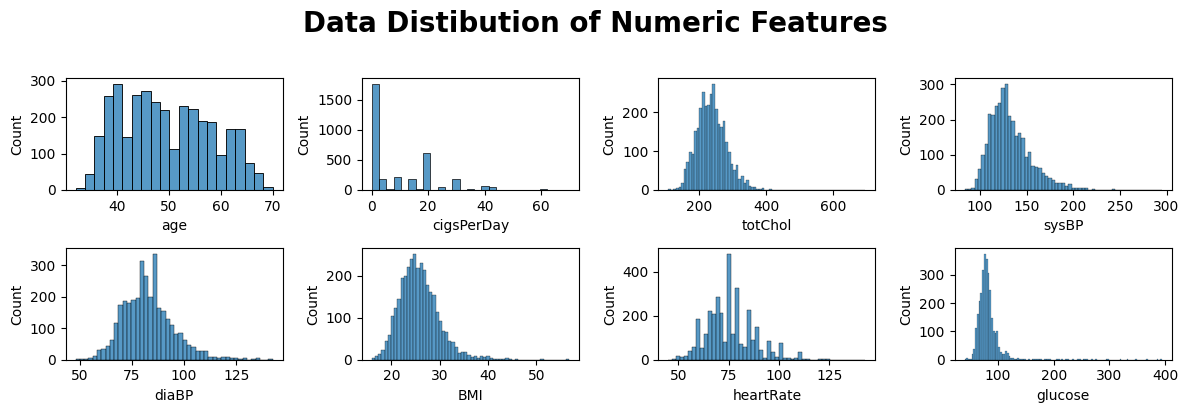

In [139]:
'''Data Distribution of Numeric features'''

plt.figure(figsize=(12,4))

plt.suptitle('Data Distibution of Numeric Features', fontsize=20, fontweight='bold', y=1.02)

for i,col in enumerate(numeric_features):

  plt.subplot(2, 4, i+1)                       # subplots 2 rows, 4 columns

  # kde plots
  sns.histplot(risk_df[col])  
  # x-axis label
  plt.xlabel(col)
plt.tight_layout()

Insight from histogram=> cigsPerDay: Many values are 0, meaning many participants do not smoke,smaller groups smoke 20 cigarettes per day,The histogram is highly right-skewed.

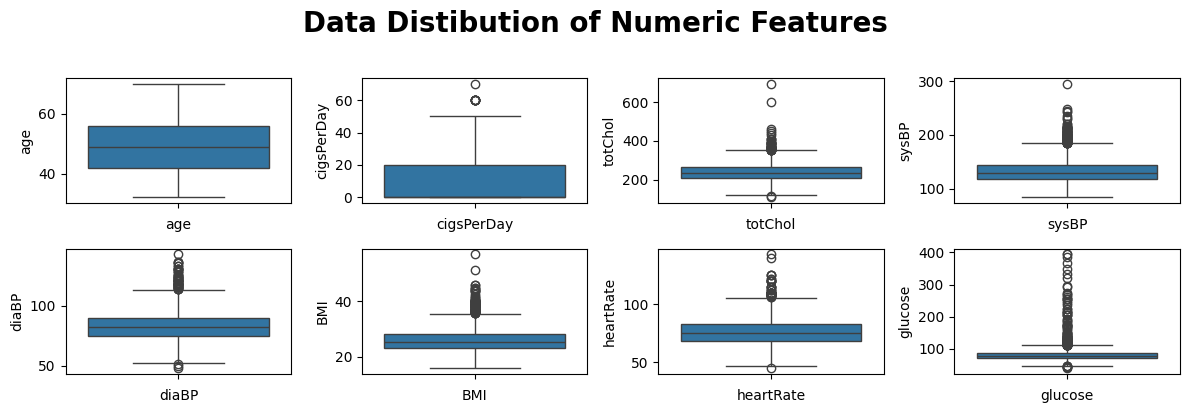

In [140]:
plt.figure(figsize=(12,4))

plt.suptitle('Data Distibution of Numeric Features', fontsize=20, fontweight='bold', y=1.02)

for i,col in enumerate(numeric_features):

  plt.subplot(2, 4, i+1)                       # subplots 2 rows, 4 columns

  # kde plots
  sns.boxplot(risk_df[col])  
  # x-axis label
  plt.xlabel(col)
plt.tight_layout()

### Analysis

The boxplot of BMI,sysBP shows several outliers above the upper whisker.

The boxplot of diaBP,heartRate,glucose shows several outliers above the upper whisker and many below the lower whisker.

cigsPerDay shows few outliers above the upper whisker.

glucose,cigsPerDay are highly right skewed as for cigsPerDay 75 percent people cigsPerDay count is less than 20 and for glucose 75 percent people glucose value is less than 87.

sysBP,totChol are right skewed.

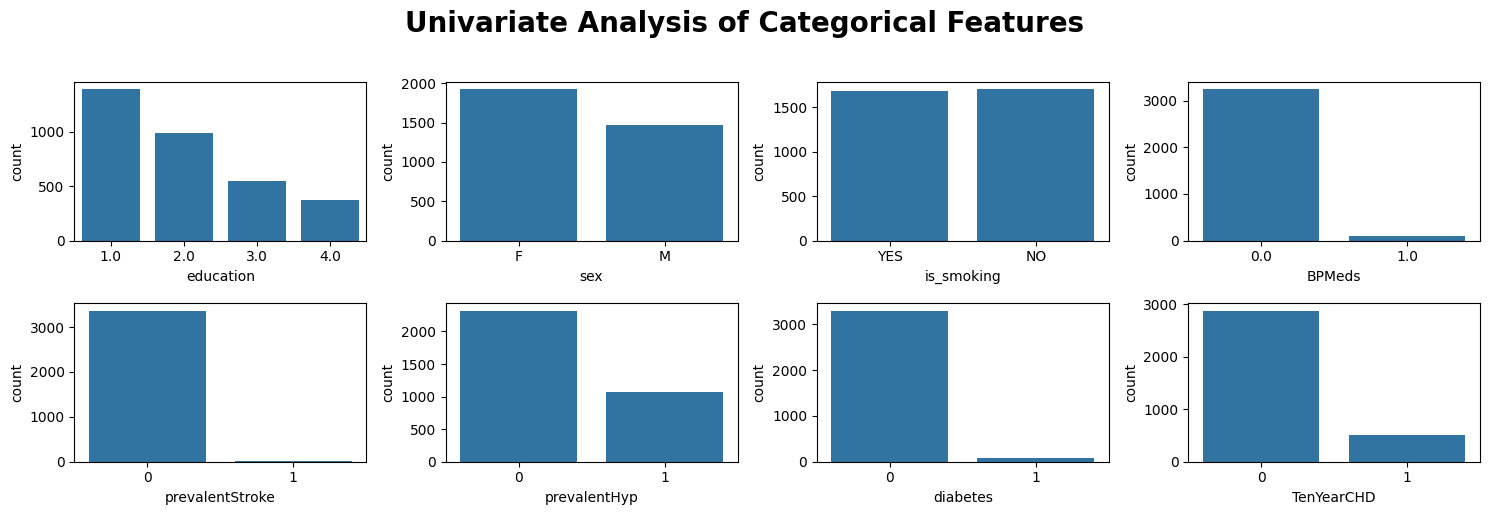

In [141]:
# figsize
plt.figure(figsize=(15,5))
# title
plt.suptitle('Univariate Analysis of Categorical Features', fontsize=20, fontweight='bold', y=1.02)

for i,col in enumerate(categorical_features):
  plt.subplot(2, 4, i+1)            # subplot of 2 rows and 4 columns

  # countplot
  sns.countplot(x=risk_df[col])
  # x-axis label
  plt.xlabel(col)
plt.tight_layout()

<span style="color:orange"> The countplot for TenYearCHD is severely skewed. Roughly 85% of participants do not develop CHD hence model might achieve high "accuracy" simply by predicting everyone is healthy</span>

<span style="color:orange">Observed significant class imbalance in binary predictors (BPMeds, prevalentStroke, Diabetes)</span>

### plotting graph to analyze age with respect to heartrate which are having Disease or No Disease

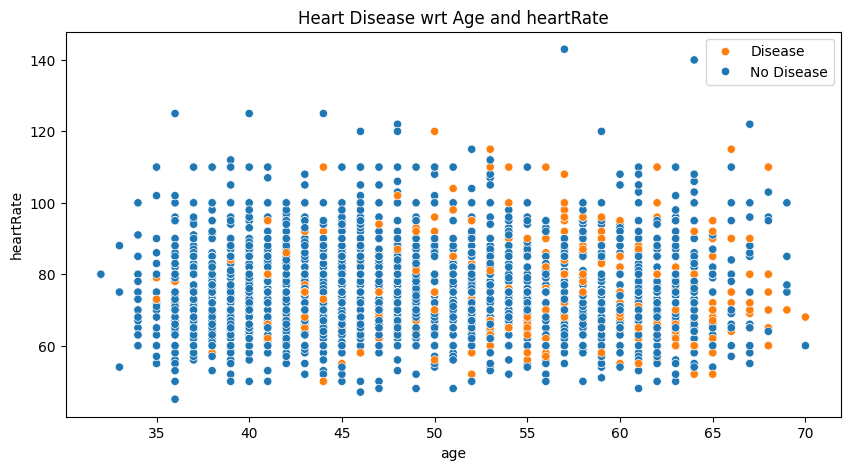

In [142]:
# figsize
plt.figure(figsize=(10,5))
# scatterplot
sns.scatterplot(x=risk_df['age'], y=risk_df['heartRate'], hue=risk_df['TenYearCHD'])
# title
plt.title('Heart Disease wrt Age and heartRate')
plt.legend(['Disease', 'No Disease'])

### Insight: younger ages.	It is rare to see CHD cases in participants under 35 in this dataset, even with high heart rates.

In [143]:
'''No benefit of this regplot as y axis reperesent yes or no and this plot is highly 
effected by outliers so no real meaning can be drawn'''

# # Checking Linearity of all numerical features with our target variable

# # figsize
# plt.figure(figsize=(15,5))
# # title
# plt.suptitle('Bivariate Analysis of Numerical features', fontsize=20, fontweight='bold', y=1.02)

# for i,col in enumerate(numeric_features[1:]):
#   plt.subplot(2, 4, i+1)                     # subplots of 2 rows and 4 columns

#   # regression plots
#   sns.regplot(x=risk_df[col], y=risk_df['TenYearCHD'])
#   # x-axis lable
#   plt.xlabel(col)
#   plt.tight_layout()

'No benefit of this regplot as y axis reperesent yes or no and this plot is highly \neffected by outliers so no real meaning can be drawn'

### Counting number of category present in each feature with respect to target feature  

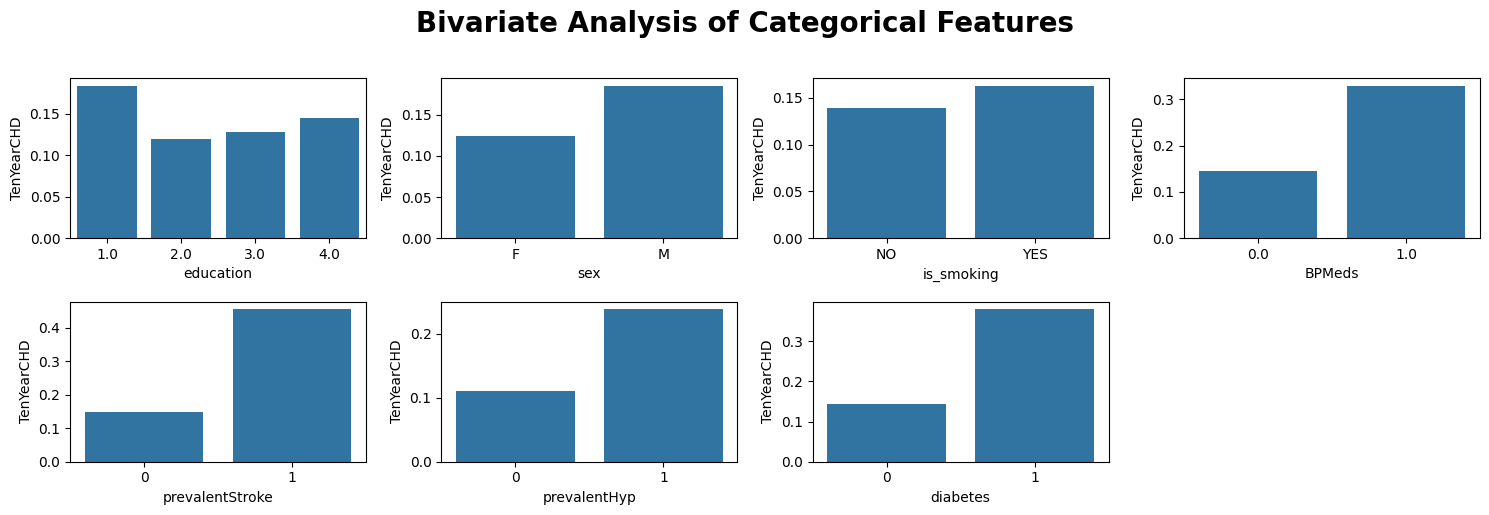

In [144]:
plt.figure(figsize=(15,5))
# title
plt.suptitle('Bivariate Analysis of Categorical Features', fontsize=20, fontweight='bold', y=1.02)

for i,col in enumerate(categorical_features[:-1]):       # taking all features in categoric column except target feature(TenYearCHD) 
  plt.subplot(2, 4, i+1)                                 # subplots of 2 rows and 4 columns
  a = risk_df.groupby(col)[['TenYearCHD']].mean().reset_index()

  # barplot
  sns.barplot(x=a[col], y=a['TenYearCHD'])
  # x-axis label
  plt.xlabel(col)
plt.tight_layout()

<span style="color:orange; font-size:24px"> Insight: although the proportion of people with prevalentStroke,diabetes,BPMeds is low but those who have this medical condition are at high risk for chd this imbalance needs to be passed with care to models means proper hyperparameter tuning required eg class_weight='balanced for SVM, setting min_leaf do decision trees</span> 

### Deal with missing values

In [145]:
# features which has less than 5%  null values present. 

nan_columns = ['education', 'cigsPerDay', 'BPMeds', 'totChol', 'BMI', 'heartRate']
risk_df.dropna(subset=nan_columns, inplace=True)

In [146]:
risk_df.shape

(3189, 16)

## using KNN Imputer for glucose values
### glucose level are continuous in nature 

In [147]:
from sklearn.impute import KNNImputer
knn=KNNImputer(weights='distance')
risk_df['glucose']=knn.fit_transform(risk_df[['glucose']])
risk_df['glucose'].isnull().sum()

np.int64(0)

### plot mean, median line to check skewness if mean = median then normal if mean > median then positively skewed if mean < median then negatively skewed

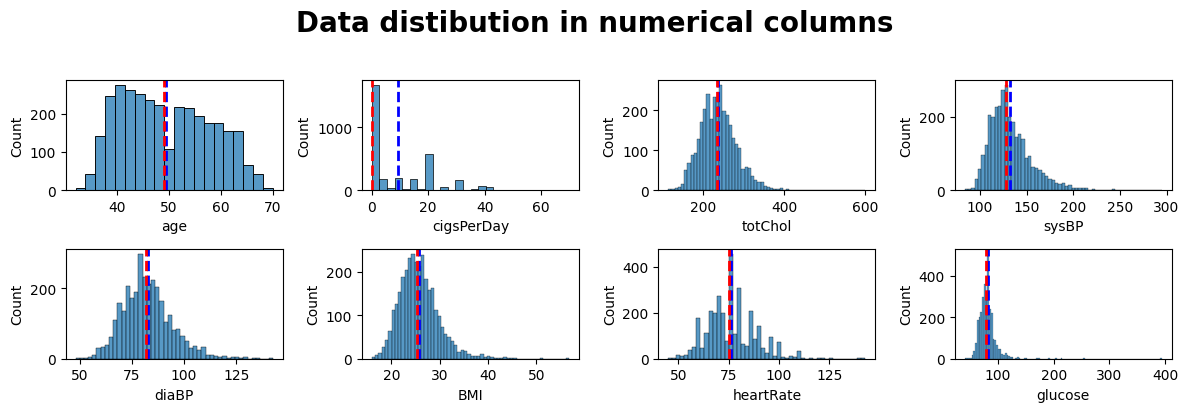

In [148]:
# figsize
plt.figure(figsize=(12,4))
# title
plt.suptitle('Data distibution in numerical columns', fontsize=20, fontweight='bold', y=1.02)

for i,col in enumerate(numeric_features):
  plt.subplot(2, 4, i+1)                      # subplots of 2 rows and 4 columns

  # distplot
  sns.histplot(risk_df[col]) 
  # mean line  
  plt.axvline(risk_df[col].mean(), color='blue', linestyle='dashed', linewidth=2)
  # median line
  plt.axvline(risk_df[col].median(), color='red', linestyle='dashed', linewidth=2)   
  # x-axis label
  plt.xlabel(col)
plt.tight_layout()

## Handling outliers
### using capping method

In [149]:
def clip_outliers(risk_df):
    for col in risk_df[numeric_features]:
        # using IQR method to define range of upper and lower limit.
        q1 = risk_df[col].quantile(0.25)
        q3 = risk_df[col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        
        # replacing the outliers with upper and lower bound
        risk_df[col] = risk_df[col].clip(lower_bound, upper_bound)
    return risk_df

In [150]:
# using the function to treat outliers
risk_df = clip_outliers(risk_df)

 <span style="color:orange"> checking the boxplot after outlier treatment </span>

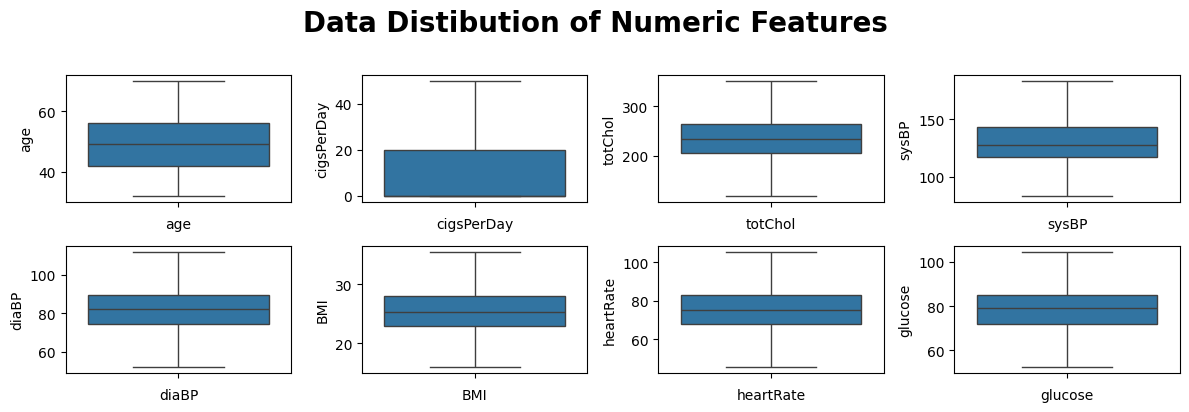

In [151]:
plt.figure(figsize=(12,4))

plt.suptitle('Data Distibution of Numeric Features', fontsize=20, fontweight='bold', y=1.02)

for i,col in enumerate(numeric_features):

  plt.subplot(2, 4, i+1)                       # subplots 2 rows, 4 columns

  # kde plots
  sns.boxplot(y=risk_df[col])  
  # x-axis label
  plt.xlabel(col)
  
plt.tight_layout()

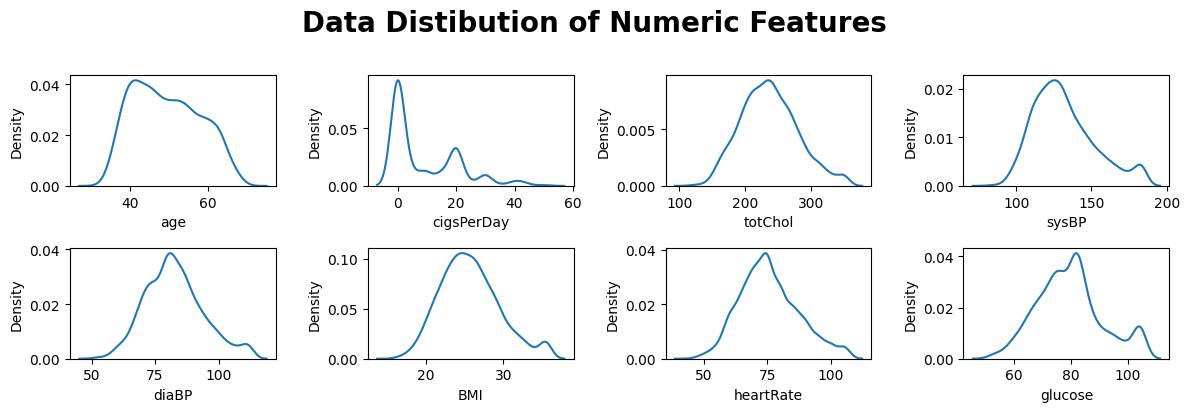

In [152]:
# checking for distribution after treating outliers.
plt.figure(figsize=(12,4))

plt.suptitle('Data Distibution of Numeric Features', fontsize=20, fontweight='bold', y=1.02)

for i,col in enumerate(numeric_features):
  plt.subplot(2, 4, i+1)                       # subplots 2 rows, 4 columns
  # kde plots
  sns.kdeplot(risk_df[col])  
  # x-axis label
  plt.xlabel(col)
plt.tight_layout()

In [153]:
risk_df['sex'] = risk_df['sex'].map({'M':1, 'F':0})
risk_df['is_smoking'] = risk_df['is_smoking'].map({'YES':1, 'NO':0})

In [154]:
# Check Unique Values for each categorical variable.
for i in categorical_features:
  print("No. of unique values in",i,"is",risk_df[i].nunique())

No. of unique values in education is 4
No. of unique values in sex is 2
No. of unique values in is_smoking is 2
No. of unique values in BPMeds is 2
No. of unique values in prevalentStroke is 2
No. of unique values in prevalentHyp is 2
No. of unique values in diabetes is 2
No. of unique values in TenYearCHD is 2


In [155]:
# dropping our target variable from categorical features list
categorical_features.remove('TenYearCHD')

In [156]:
# one-hot encode the 'education' feature
dummies = pd.get_dummies(risk_df['education'])
dummies.columns = [
    'education_1',
    'education_2',
    'education_3',
    'education_4'
]

# concatenate the one-hot encoded education feature with the rest of the data
risk_df = pd.concat([risk_df, dummies], axis=1)
# drop the original education feature
risk_df=risk_df.drop(['education','education_4'], axis=1,errors='ignore')
risk_df.head(3)

,age,sex,is_smoking,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD,education_1,education_2,education_3
1,36,1,0,0.0,0.0,0,1,0,212.0,168.0,98.0,29.77,72.0,75.0,0,False,False,False
2,46,0,1,10.0,0.0,0,0,0,250.0,116.0,71.0,20.35,88.0,94.0,0,True,False,False
3,50,1,1,20.0,0.0,0,1,0,233.0,158.0,88.0,28.26,68.0,94.0,1,True,False,False


<Axes: >

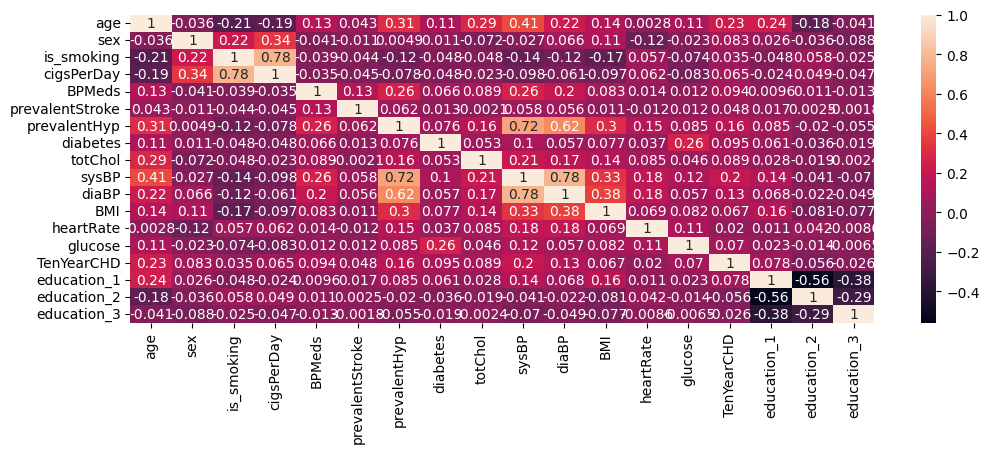

In [157]:
# Plotting correlation heatmap
plt.figure(figsize=(12,4))
sns.heatmap(risk_df.corr(),annot=True)

Multicollinearity happens when features contain almost the same information, making weight-based models unable to assign stable and meaningful coefficients.

Highly correlated features make it impossible for weight-based models to uniquely and stably determine the coefficients.

This ain't an issue with split based models.

In [158]:
'''find and remove correlated features'''

def correlation(dataset, threshold):
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold:        # we are interested in absolute coeff value
                print(
                    corr_matrix.columns[i],",",
                    corr_matrix.columns[j],
                )


In [159]:
# checking the highly correlated features
correlation(risk_df, 0.7)

cigsPerDay , is_smoking
sysBP , prevalentHyp
diaBP , sysBP


In [160]:
# checking data, weather the provide information is correct or not
inconsistency_in_data=risk_df[(risk_df.is_smoking == 'YES') & (risk_df.cigsPerDay == 0)] # it will return those rows where is_smoking is yes but cigsPerDay is 0
inconsistency_in_data

,age,sex,is_smoking,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD,education_1,education_2,education_3


Insight: Hence not inconsistent data and is_smoking information can be derived from cigsPerDay hence drop is_smoking feature

In [161]:
risk_df=risk_df.drop(['is_smoking'],axis=1,errors='ignore')

In [162]:
risk_df['sysBP'].corr(risk_df['TenYearCHD'])

np.float64(0.20202320505484728)

In [163]:
risk_df['diaBP'].corr(risk_df['TenYearCHD'])

np.float64(0.13061681337643963)

hence reomove diaBP

In [164]:
risk_df=risk_df.drop(['diaBP','prevalentHyp'],axis=1,errors='ignore')
risk_df.sample(2)

,age,sex,cigsPerDay,BPMeds,prevalentStroke,diabetes,totChol,sysBP,BMI,heartRate,glucose,TenYearCHD,education_1,education_2,education_3
2825,48,1,25.0,0.0,0,0,249.0,132.00,29.79,90.0,53.0,0,False,True,False
2808,59,0,0.0,1.0,0,0,320.0,183.25,25.33,75.0,68.0,0,True,False,False


In [165]:
X = risk_df.drop(columns='TenYearCHD')     # independent features
y = risk_df['TenYearCHD']                  # dependent features

In [166]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=33)

In [167]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [168]:
# empty list for appending performance metric score 
model_result = []

In [169]:
def predict(ml_model_object, model_name):
  
  '''
  Pass the model and predict value. 
  Function will calculate all the eveluation metrics and appending those metrics score on model_result table.
  Plotting confusion_matrix for test data.
  ''' 
  
  # model fitting
  ml_model_object.fit(X_train, y_train)
  
  # predicting value and probability
  y_train_pred = ml_model_object.predict(X_train)
  y_test_pred = ml_model_object.predict(X_test)
  y_train_prob = ml_model_object.predict_proba(X_train)[:,1]
  y_test_prob = ml_model_object.predict_proba(X_test)[:,1]


  ''' Performance Metrics ''' 
  # accuracy score  ---->  (TP+TN)/(TP+FP+TN+FN)
  train_accuracy = accuracy_score(y_train, y_train_pred) 
  test_accuracy = accuracy_score(y_test, y_test_pred)
  print(f'train accuracy : {round(train_accuracy,3)}')
  print(f'test accuracy : {round(test_accuracy,3)}')

  # precision score  ---->  TP/(TP+FP)
  train_precision = precision_score(y_train, y_train_pred)
  test_precision = precision_score(y_test, y_test_pred)
  print(f'train precision : {round(train_precision,3)}')
  print(f'test precision : {round(test_precision,3)}')

  # recall score  ---->  TP/(TP+FN)
  train_recall = recall_score(y_train, y_train_pred)
  test_recall = recall_score(y_test, y_test_pred)
  print(f'train recall : {round(train_recall,3)}')
  print(f'test recall : {round(test_recall,3)}')
  
  # f1 score  ---->  Harmonic Mean of Precision and Recall
  train_f1 = f1_score(y_train, y_train_pred)
  test_f1 = f1_score(y_test, y_test_pred)
  print(f'train f1 : {round(train_f1,3)}')
  print(f'test f1 : {round(test_f1,3)}')
  print('-'*80)

  # roc_auc score  ---->  It shows how well the model can differentiate between classes.
  train_roc_auc = roc_auc_score(y_train, y_train_prob)
  test_roc_auc = roc_auc_score(y_test, y_test_prob)
  print(f'train roc_auc : {round(train_roc_auc,3)}')
  print(f'test roc_auc : {round(test_roc_auc,3)}')
  print('-'*80)


  ''' plotting Confusion Matrix '''
  ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred)
  plt.title('confusion matrix on Test data', weight='bold')
  plt.show()
  print('-'*80)

  ''' plotting ROC curve '''
  fpr, tpr, threshold = roc_curve(y_test, y_test_prob)
  plt.plot(fpr,tpr, label=f'ROC - {model_name}')
  plt.plot([0,1], [0,1], '--')
  plt.title('ROC curve on Test data', weight='bold')
  plt.xlabel('False Positive Rate----->')
  plt.ylabel('True Positive Rate----->')
  plt.legend(loc=4)


  ''' actual value vs predicted value on test data'''
  d = {'y_actual':y_test, 'y_predict':y_test_pred}
  print(pd.DataFrame(data=d).head(10).T)                   # constructing a dataframe with both actual and predicted values
  print('-'*80)


  # using the score from the performance metrics to create the final model_result.
  model_result.append({'model':model_name,
                       'train_accuracy':train_accuracy, 
                       'test_accuracy':test_accuracy, 
                       'train_precision':train_precision,
                       'test_precision':test_precision,
                       'train_recall':train_recall,
                       'test_recall':test_recall,
                       'train_f1':train_f1,
                       'test_f1':test_f1})
  
  print()



In [170]:
# Checking the optimum value of the k:
accuracy=[]

# Iterating for the optimum value of k
for i in range(1,15):
  knn=KNeighborsClassifier(n_neighbors=i)
  knn.fit(X_train,y_train)
  accuracy.append(knn.score(X_test, y_test))

### plotting the k-value vs accuracy


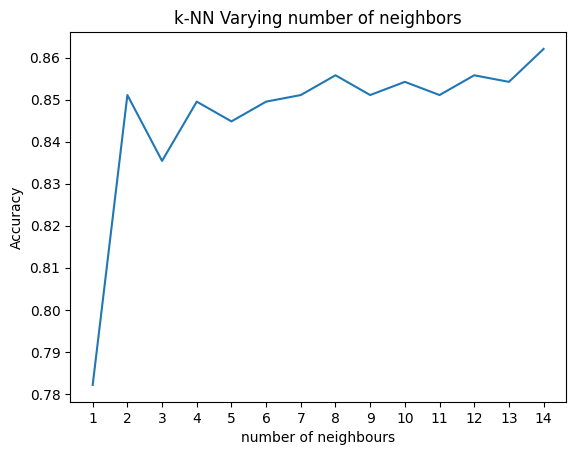

In [171]:
plt.title('k-NN Varying number of neighbors')
plt.plot(range(1,15), accuracy)
plt.xticks(range(1,15))
plt.xlabel('number of neighbours')
plt.ylabel('Accuracy')
plt.show()  

### Insight: The best accuracy is at K=14. For binary classification, k is typically an odd number (to prevent ties) of at least three. Hence use k=13

train accuracy : 0.858
test accuracy : 0.859
train precision : 0.857
test precision : 0.375
train recall : 0.078
test recall : 0.034
train f1 : 0.142
test f1 : 0.062
--------------------------------------------------------------------------------
train roc_auc : 0.73
test roc_auc : 0.72
--------------------------------------------------------------------------------


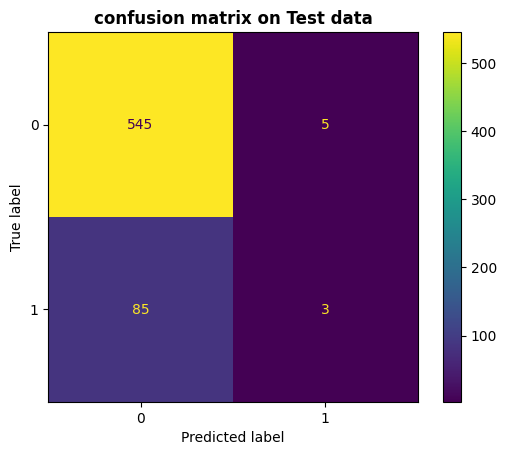

--------------------------------------------------------------------------------
           2203  2070  2235  2922  2694  875   338   3372  2383  361 
y_actual      0     0     0     0     0     1     0     0     0     0
y_predict     0     0     0     0     0     1     0     0     0     0
--------------------------------------------------------------------------------

train accuracy : 0.857
test accuracy : 0.859
train precision : 1.0
test precision : 0.25
train recall : 0.057
test recall : 0.011
train f1 : 0.108
test f1 : 0.022
--------------------------------------------------------------------------------
train roc_auc : 0.826
test roc_auc : 0.55
--------------------------------------------------------------------------------


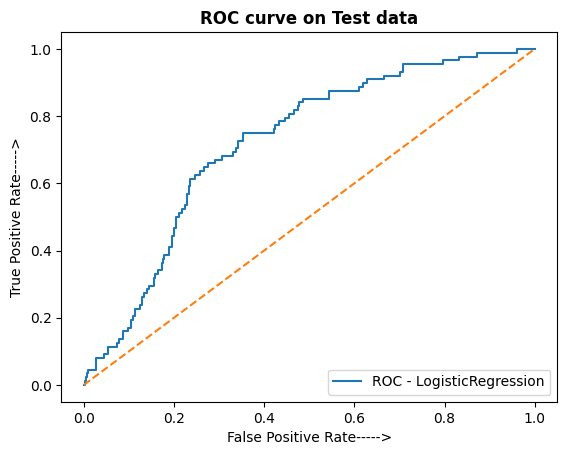

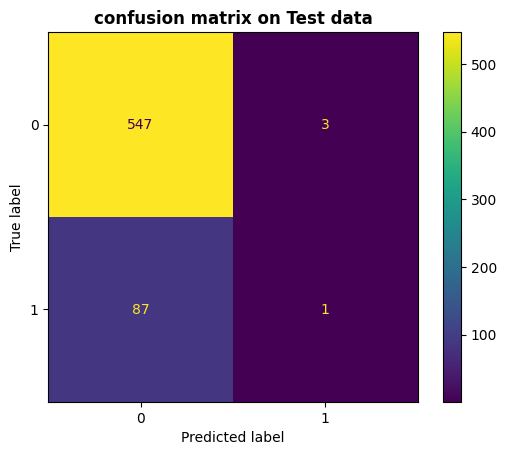

--------------------------------------------------------------------------------
           2203  2070  2235  2922  2694  875   338   3372  2383  361 
y_actual      0     0     0     0     0     1     0     0     0     0
y_predict     0     0     0     0     0     0     0     0     0     0
--------------------------------------------------------------------------------

train accuracy : 1.0
test accuracy : 0.732
train precision : 1.0
test precision : 0.173
train recall : 1.0
test recall : 0.25
train f1 : 1.0
test f1 : 0.205
--------------------------------------------------------------------------------
train roc_auc : 1.0
test roc_auc : 0.53
--------------------------------------------------------------------------------


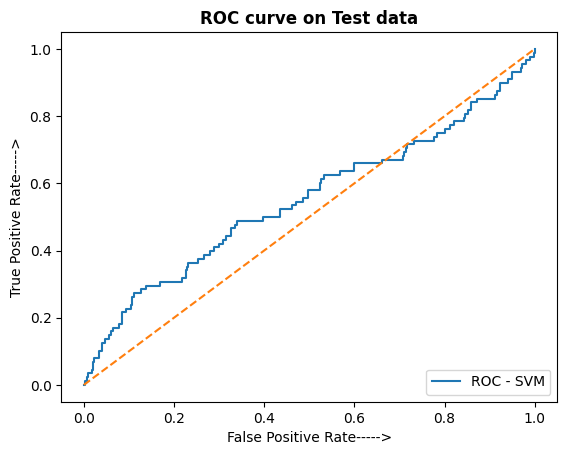

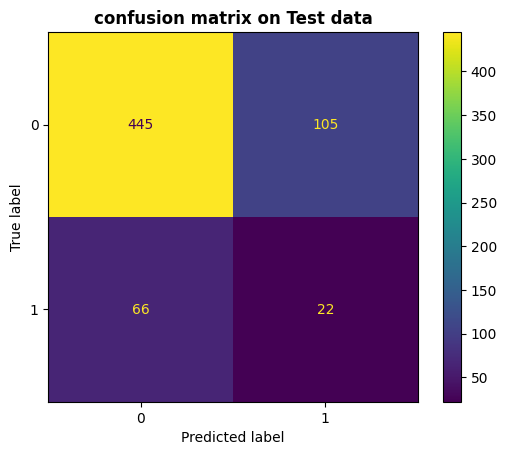

--------------------------------------------------------------------------------
           2203  2070  2235  2922  2694  875   338   3372  2383  361 
y_actual      0     0     0     0     0     1     0     0     0     0
y_predict     0     0     0     0     0     1     0     0     0     0
--------------------------------------------------------------------------------

train accuracy : 1.0
test accuracy : 0.782
train precision : 1.0
test precision : 0.193
train recall : 1.0
test recall : 0.182
train f1 : 1.0
test f1 : 0.187
--------------------------------------------------------------------------------
train roc_auc : 1.0
test roc_auc : 0.53
--------------------------------------------------------------------------------


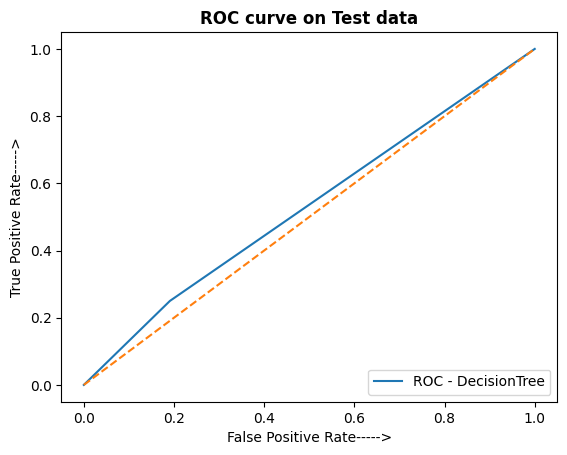

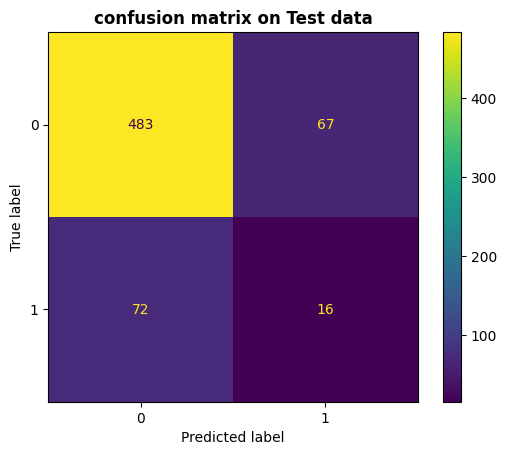

--------------------------------------------------------------------------------
           2203  2070  2235  2922  2694  875   338   3372  2383  361 
y_actual      0     0     0     0     0     1     0     0     0     0
y_predict     0     0     0     0     1     0     0     0     0     0
--------------------------------------------------------------------------------



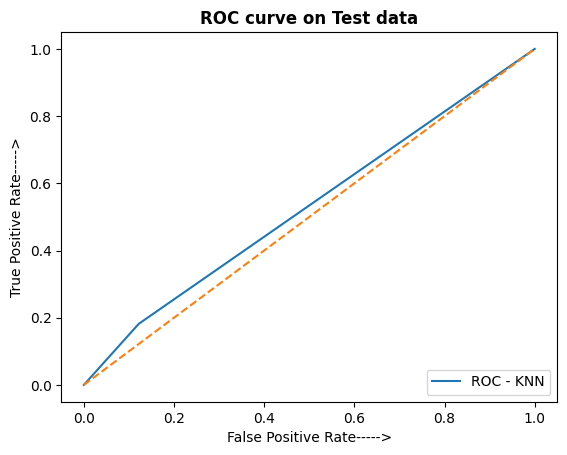

In [172]:
predict(LogisticRegression(), 'LogisticRegression')
predict(SVC(probability=True), 'SVM')
predict(DecisionTreeClassifier(), 'DecisionTree')
predict(KNeighborsClassifier(n_neighbors=1), 'KNN')


In [173]:
#converting model_result to DataFrame
model_result = pd.DataFrame(model_result)
round(model_result,3)


,model,train_accuracy,test_accuracy,train_precision,test_precision,train_recall,test_recall,train_f1,test_f1
0,LogisticRegression,0.858,0.859,0.857,0.375,0.078,0.034,0.142,0.062
1,SVM,0.857,0.859,1.000,0.250,0.057,0.011,0.108,0.022
2,DecisionTree,1.000,0.732,1.000,0.173,1.000,0.250,1.000,0.205
3,KNN,1.000,0.782,1.000,0.193,1.000,0.182,1.000,0.187


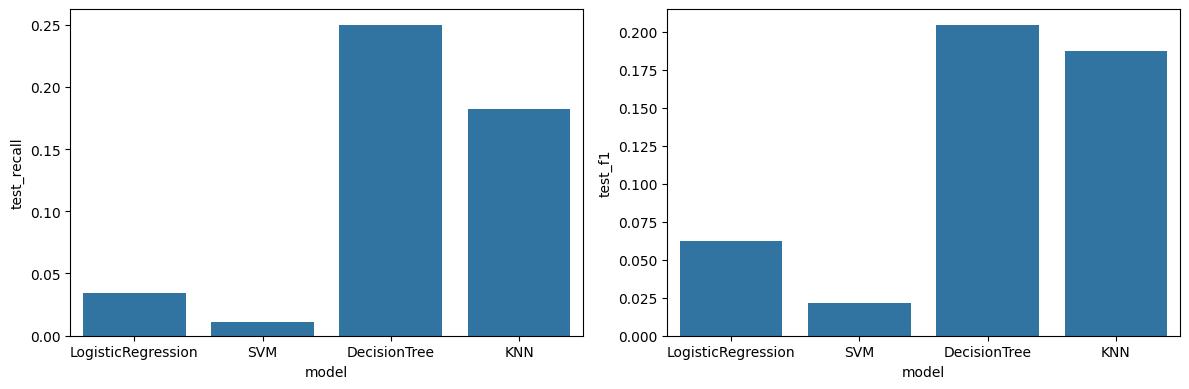

In [174]:
# plotting graph to compaire model performance of all the models
fig, axs = plt.subplots(1,2, figsize=(12,4))
sns.barplot(x=model_result['model'], y=model_result['test_recall'], ax=axs[0])   # Model vs Recall score
sns.barplot(x=model_result['model'], y=model_result['test_f1'], ax=axs[1])       # Model vs F1 score 
plt.tight_layout()